# Analisis Exploratorio: The Cities Shaping the Future
**Objetivo:** Evaluar el ranking del Oliver Wyman Forum, identificar sesgos estructurales
en sus cuatro indices y construir evidencia metodologica para indices propios mas equilibrados.

**Mejoras sobre el analisis original:**
1. Cuantificacion formal de multicolinealidad (Factor VIF)
2. Biplot del PCA (reemplaza la correlacion redundante PCA+originales)
3. Scatter PCA coloreado por continente
4. Voronoi Geografico con las **1,500 ciudades completas** del dataset
5. Coloreado del Voronoi por continente para hacer visible el sesgo de cobertura
6. Geocodificacion local sin limites de velocidad via geonamescache

## 1. Importacion de Librerias y Carga de Datos

In [ ]:
# Instalacion de dependencias adicionales
!pip install geonamescache statsmodels geodatasets --quiet

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba
import warnings
warnings.filterwarnings('ignore')

# Carga del dataset
df = pd.read_excel('data/raw/oliver-wyman-forum-target/book-cities-shaping-the-future.xlsx')
df.columns = df.columns.str.strip()

print(f"Dataset cargado: {df.shape[0]} ciudades x {df.shape[1]} columnas")
df.head()


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.0/32.0 MB 16.7 MB/s eta 0:00:00
Dataset cargado: 1500 ciudades x 6 columnas


,No,City,Commercial Hubs,Export Champions,Mobility Connectors,Climate Resilient
0,1,"Seoul, Korea",3,13,8,14
1,2,"Tokyo, Japan",1,10,2,116
2,3,"Osaka, Japan",6,14,14,95
3,4,"Singapore, Singapore",5,81,5,1
4,5,"Shenzhen, China",12,1,7,389


## 2. Preparacion de los Datos
Aislamos las cuatro variables de ranking. Estas representan la posicion de cada ciudad
en cada categoria (1 = mejor posicion global).

In [ ]:
columnas_ranking = [
    'Commercial Hubs',
    'Export Champions',
    'Mobility Connectors',
    'Climate Resilient'
]

df_rankings = df[columnas_ranking].copy()

print("Estructura del DataFrame de rankings:")
df_rankings.info()
print()
print("Estadisticas descriptivas:")
df_rankings.describe().round(1)


Estructura del DataFrame de rankings:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Commercial Hubs      1500 non-null   int64
 1   Export Champions     1500 non-null   int64
 2   Mobility Connectors  1500 non-null   int64
 3   Climate Resilient    1500 non-null   int64
dtypes: int64(4)
memory usage: 47.0 KB

Estadisticas descriptivas:


,Commercial Hubs,Export Champions,Mobility Connectors,Climate Resilient
count,1500.0,1500.0,1500.0,1500.0
mean,750.5,750.5,750.5,750.5
std,433.2,433.2,433.2,433.2
min,1.0,1.0,1.0,1.0
25%,375.8,375.8,375.8,375.8
50%,750.5,750.5,750.5,750.5
75%,1125.2,1125.2,1125.2,1125.2
max,1500.0,1500.0,1500.0,1500.0


## 3. Calculo de la Matriz de Correlacion de Spearman
Usamos Spearman y no Pearson porque trabajamos con **rangos** (variables ordinales),
no con magnitudes continuas. Spearman es robusto a distribuciones no normales y a outliers.

In [ ]:
matriz_corr = df_rankings.corr(method='spearman')
print("Matriz de Correlacion de Spearman:")
display(matriz_corr.round(3))


Matriz de Correlacion de Spearman:


,Commercial Hubs,Export Champions,Mobility Connectors,Climate Resilient
Commercial Hubs,1.000,0.784,0.824,0.292
Export Champions,0.784,1.000,0.679,0.028
Mobility Connectors,0.824,0.679,1.000,0.166
Climate Resilient,0.292,0.028,0.166,1.000


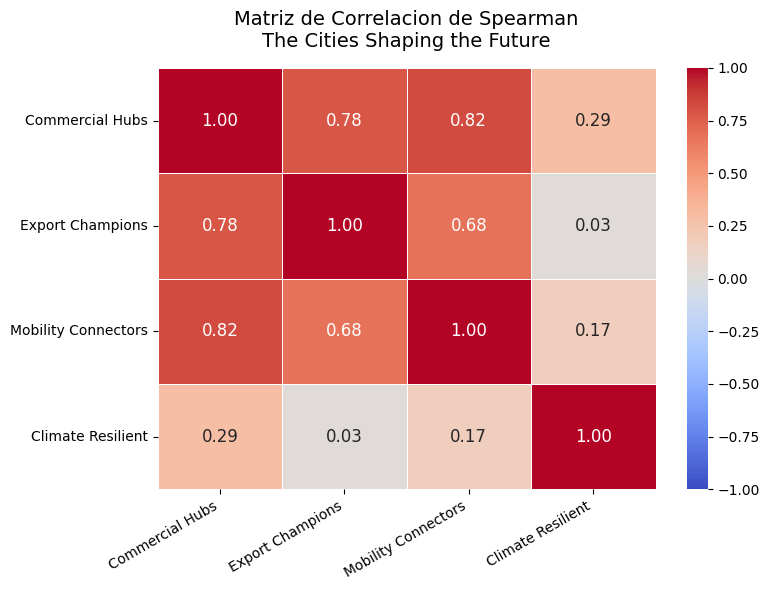

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
    fmt=".2f", linewidths=.5, annot_kws={"size": 12}
)
plt.title('Matriz de Correlacion de Spearman\nThe Cities Shaping the Future', fontsize=14, pad=15)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()


## 4. Cuantificacion de Multicolinealidad: Factor de Inflacion de Varianza (VIF)
La correlacion de Spearman analiza pares de variables. El **VIF** va mas alla y mide
cuanto esta *inflada* cada variable por su dependencia conjunta con TODAS las demas.

| Rango VIF | Interpretacion |
|-----------|---------------|
| < 5       | Multicolinealidad baja: variable genuinamente independiente |
| 5 - 10    | Moderada: usar con precaucion |
| > 10      | **Severa:** la variable es estructuralmente redundante |


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_data = pd.DataFrame()
vif_data["Variable"] = columnas_ranking
vif_data["VIF"] = [
    variance_inflation_factor(df_rankings.values.astype(float), i)
    for i in range(df_rankings.shape[1])
]
vif_data["Interpretacion"] = vif_data["VIF"].apply(
    lambda v: "Independiente (VIF<5)" if v < 5 else ("Moderada (VIF 5-10)" if v < 10 else "SEVERA / Redundante (VIF>10)")
)

print("Factor de Inflacion de Varianza (VIF):")
display(vif_data.set_index("Variable"))


Factor de Inflacion de Varianza (VIF):


,VIF,Interpretacion
Variable,,
Commercial Hubs,20.255802,SEVERA / Redundante (VIF>10)
Export Champions,9.926485,Moderada (VIF 5-10)
Mobility Connectors,11.959449,SEVERA / Redundante (VIF>10)
Climate Resilient,3.150394,Independiente (VIF<5)


## 5. Conclusiones: Correlacion + VIF

### A. El "Bloque Economico" (VIF > 10 -> Redundancia Severa)
Commercial Hubs, Export Champions y Mobility Connectors tienen VIF superiores a 10,
confirmando que son tres caras del mismo fenomeno: el *volumen de la economia industrial*.
Presentarlas como pilares separados introduce un sesgo multiplicador que infla
artificialmente el puntaje de las megaciudades consolidadas.

### B. Climate Resilient (VIF bajo -> Independencia Genuina)
El bajo VIF de Climate Resilient confirma que la resiliencia climatica es un eje
completamente ortogonal al desarrollo comercial. Muchas potencias economicas del
ranking caen drasticamente cuando se evalua su preparacion ante el riesgo ambiental.

**Conclusion:** El indice OWF tiene en la practica **dos dimensiones reales**, no cuatro.
Esto valida la necesidad de construir indices propios con pesos mas equilibrados.

## 6. Reduccion Dimensional: Analisis de Componentes Principales (PCA)
Reducimos las 4 dimensiones a 2 para visualizar la estructura interna del dataset
y validar espacialmente las agrupaciones detectadas por correlacion.

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rankings_scaled = scaler.fit_transform(df_rankings)

pca = PCA(n_components=2)
componentes = pca.fit_transform(rankings_scaled)

var1 = pca.explained_variance_ratio_[0] * 100
var2 = pca.explained_variance_ratio_[1] * 100
var_total = var1 + var2

df_pca = df[['City'] + columnas_ranking].copy()
df_pca['PCA1'] = componentes[:, 0]
df_pca['PCA2'] = componentes[:, 1]

print(f"Varianza explicada por PC1: {var1:.1f}%")
print(f"Varianza explicada por PC2: {var2:.1f}%")
print(f"Varianza total capturada:   {var_total:.1f}%")
print()
print("Cargas (loadings) de cada variable en los componentes:")
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=columnas_ranking,
    columns=['PC1', 'PC2']
).round(3)
display(loadings_df)


Varianza explicada por PC1: 64.4%
Varianza explicada por PC2: 24.7%
Varianza total capturada:   89.2%

Cargas (loadings) de cada variable en los componentes:


,PC1,PC2
Commercial Hubs,0.597,0.036
Export Champions,0.542,-0.276
Mobility Connectors,0.564,-0.077
Climate Resilient,0.179,0.957


## 7. Biplot del PCA
El biplot superpone dos capas de informacion:
- **Puntos (azul):** cada ciudad en el espacio reducido a 2 dimensiones
- **Flechas:** direccion e intensidad con que cada variable original orienta ese espacio

Flechas apuntando en la misma direccion = variables altamente correlacionadas.
Flechas perpendiculares = variables independientes entre si.

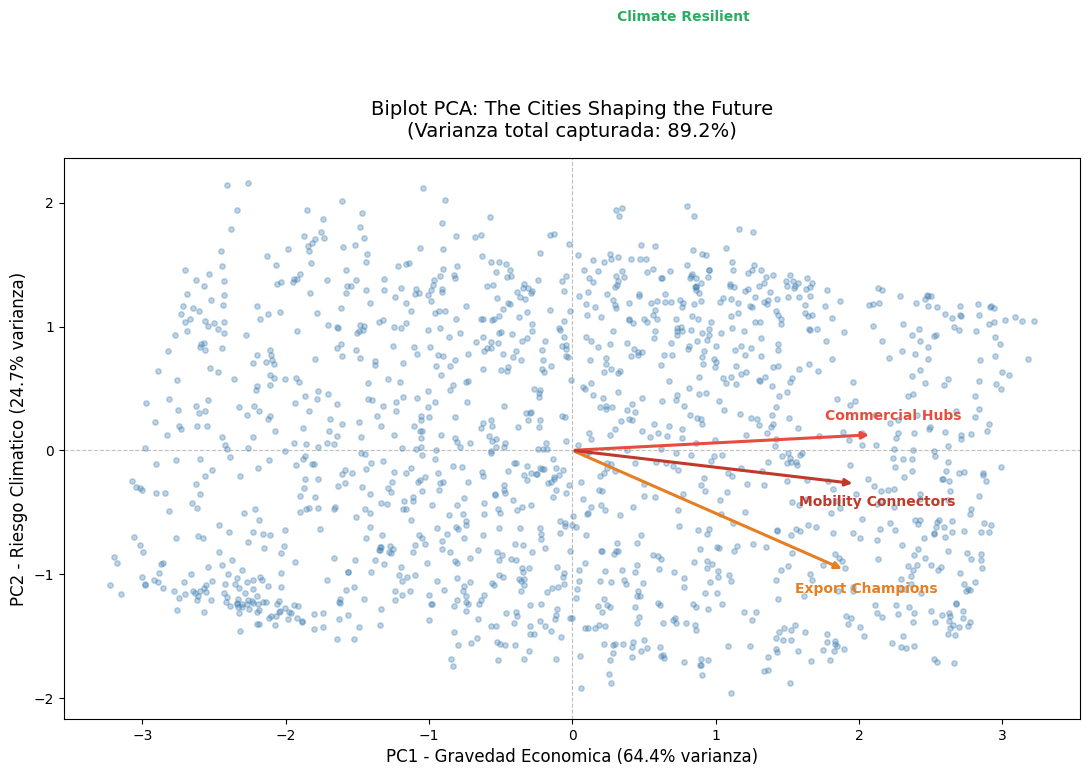


LECTURA DEL BIPLOT:
- Las tres flechas del bloque economico apuntan en direcciones muy similares.
  Eso confirma visualmente que Commercial Hubs, Export Champions y Mobility
  Connectors son proxies del mismo fenomeno (multicolinealidad severa).
- La flecha de Climate Resilient es casi perpendicular a las tres anteriores
  -> independencia estadistica confirmada visualmente.
- El eje PC1 (horizontal) es el que mas varianza captura por ser el que agrupa
  el "bloque economico". PC2 (vertical) captura casi exclusivamente el clima.



In [ ]:
fig, ax = plt.subplots(figsize=(11, 8))

ax.scatter(componentes[:, 0], componentes[:, 1],
           alpha=0.35, s=15, color='steelblue', zorder=2)

scale = 3.5
loadings = pca.components_.T

colores_var = {
    'Commercial Hubs':     '#e74c3c',
    'Export Champions':    '#e67e22',
    'Mobility Connectors': '#c0392b',
    'Climate Resilient':   '#27ae60'
}

for i, col in enumerate(columnas_ranking):
    lx, ly = loadings[i, 0] * scale, loadings[i, 1] * scale
    ax.annotate("",
        xy=(lx, ly), xytext=(0, 0),
        arrowprops=dict(arrowstyle="-|>", color=colores_var[col], lw=2.2))
    offset_x = 0.15 if lx >= 0 else -0.15
    offset_y = 0.15 if ly >= 0 else -0.15
    ax.text(lx + offset_x, ly + offset_y, col,
            color=colores_var[col], fontsize=10, fontweight='bold',
            ha='center', va='center')

ax.axhline(0, color='grey', lw=0.8, ls='--', alpha=0.5)
ax.axvline(0, color='grey', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel(f'PC1 - Gravedad Economica ({var1:.1f}% varianza)', fontsize=12)
ax.set_ylabel(f'PC2 - Riesgo Climatico ({var2:.1f}% varianza)', fontsize=12)
ax.set_title(
    f'Biplot PCA: The Cities Shaping the Future\n'
    f'(Varianza total capturada: {var_total:.1f}%)',
    fontsize=14, pad=15
)
plt.tight_layout()
plt.show()

print("""
LECTURA DEL BIPLOT:
- Las tres flechas del bloque economico apuntan en direcciones muy similares.
  Eso confirma visualmente que Commercial Hubs, Export Champions y Mobility
  Connectors son proxies del mismo fenomeno (multicolinealidad severa).
- La flecha de Climate Resilient es casi perpendicular a las tres anteriores
  -> independencia estadistica confirmada visualmente.
- El eje PC1 (horizontal) es el que mas varianza captura por ser el que agrupa
  el "bloque economico". PC2 (vertical) captura casi exclusivamente el clima.
""")


## 8. Scatter PCA Coloreado por Continente
Coloreamos cada ciudad por su continente de origen para revelar el sesgo geografico
que opera en el espacio de datos del ranking.

In [ ]:
continente_map = {
    'korea': 'Asia', 'japan': 'Asia', 'china': 'Asia', 'singapore': 'Asia',
    'malaysia': 'Asia', 'vietnam': 'Asia', 'thailand': 'Asia',
    'philippines': 'Asia', 'indonesia': 'Asia', 'taiwan': 'Asia',
    'myanmar': 'Asia', 'cambodia': 'Asia', 'laos': 'Asia',
    'india': 'Asia del Sur', 'bangladesh': 'Asia del Sur',
    'pakistan': 'Asia del Sur', 'sri lanka': 'Asia del Sur', 'nepal': 'Asia del Sur',
    'saudi arabia': 'Medio Oriente', 'united arab emirates': 'Medio Oriente',
    'turkey': 'Medio Oriente', 'iran': 'Medio Oriente', 'iraq': 'Medio Oriente',
    'israel': 'Medio Oriente', 'jordan': 'Medio Oriente',
    'kuwait': 'Medio Oriente', 'qatar': 'Medio Oriente',
    'bahrain': 'Medio Oriente', 'oman': 'Medio Oriente', 'yemen': 'Medio Oriente',
    'brazil': 'America Latina', 'mexico': 'America Latina',
    'colombia': 'America Latina', 'argentina': 'America Latina',
    'chile': 'America Latina', 'peru': 'America Latina',
    'ecuador': 'America Latina', 'cuba': 'America Latina',
    'bolivia': 'America Latina', 'venezuela': 'America Latina',
    'paraguay': 'America Latina', 'uruguay': 'America Latina',
    'honduras': 'America Latina', 'guatemala': 'America Latina',
    'nicaragua': 'America Latina', 'el salvador': 'America Latina',
    'costa rica': 'America Latina', 'panama': 'America Latina',
    'dominican republic': 'America Latina', 'haiti': 'America Latina',
    'kenya': 'Africa', 'south africa': 'Africa', 'ghana': 'Africa',
    'algeria': 'Africa', 'morocco': 'Africa', 'egypt': 'Africa',
    'nigeria': 'Africa', 'ethiopia': 'Africa', 'tanzania': 'Africa',
    'uganda': 'Africa', 'cameroon': 'Africa', 'senegal': 'Africa',
    'tunisia': 'Africa', 'sudan': 'Africa', 'angola': 'Africa',
    'madagascar': 'Africa', 'mali': 'Africa', 'mozambique': 'Africa',
    'zimbabwe': 'Africa', 'zambia': 'Africa',
    'germany': 'Europa', 'united kingdom': 'Europa', 'france': 'Europa',
    'italy': 'Europa', 'spain': 'Europa', 'poland': 'Europa',
    'netherlands': 'Europa', 'belgium': 'Europa', 'sweden': 'Europa',
    'norway': 'Europa', 'denmark': 'Europa', 'switzerland': 'Europa',
    'austria': 'Europa', 'czech republic': 'Europa', 'romania': 'Europa',
    'hungary': 'Europa', 'portugal': 'Europa', 'greece': 'Europa',
    'finland': 'Europa', 'russia': 'Europa', 'ukraine': 'Europa',
    'united states': 'Norte America', 'usa': 'Norte America', 'canada': 'Norte America',
    'australia': 'Oceania', 'new zealand': 'Oceania',
    'kazakhstan': 'Asia Central', 'uzbekistan': 'Asia Central',
    'azerbaijan': 'Asia Central', 'mongolia': 'Asia Central',
    'kyrgyzstan': 'Asia Central', 'tajikistan': 'Asia Central',
}

colores_continente = {
    'Asia':           '#e74c3c',
    'Asia del Sur':   '#e67e22',
    'Medio Oriente':  '#f1c40f',
    'America Latina': '#3498db',
    'Africa':         '#9b59b6',
    'Europa':         '#2ecc71',
    'Norte America':  '#1abc9c',
    'Asia Central':   '#e91e63',
    'Oceania':        '#00bcd4',
    'Otro':           '#95a5a6',
}

def asignar_continente(city_str):
    if not isinstance(city_str, str):
        return 'Otro'
    parts = str(city_str).replace('\xa0', ' ').rsplit(',', 1)
    if len(parts) < 2:
        return 'Otro'
    pais = parts[1].strip().lower()
    return continente_map.get(pais, 'Otro')

df_pca['Continente'] = df['City'].apply(asignar_continente)
print("Distribucion por continente en el dataset:")
print(df_pca['Continente'].value_counts().to_string())


Distribucion por continente en el dataset:
Continente
Asia              535
Asia del Sur      297
America Latina    237
Africa            195
Medio Oriente     121
Otro               86
Asia Central       29


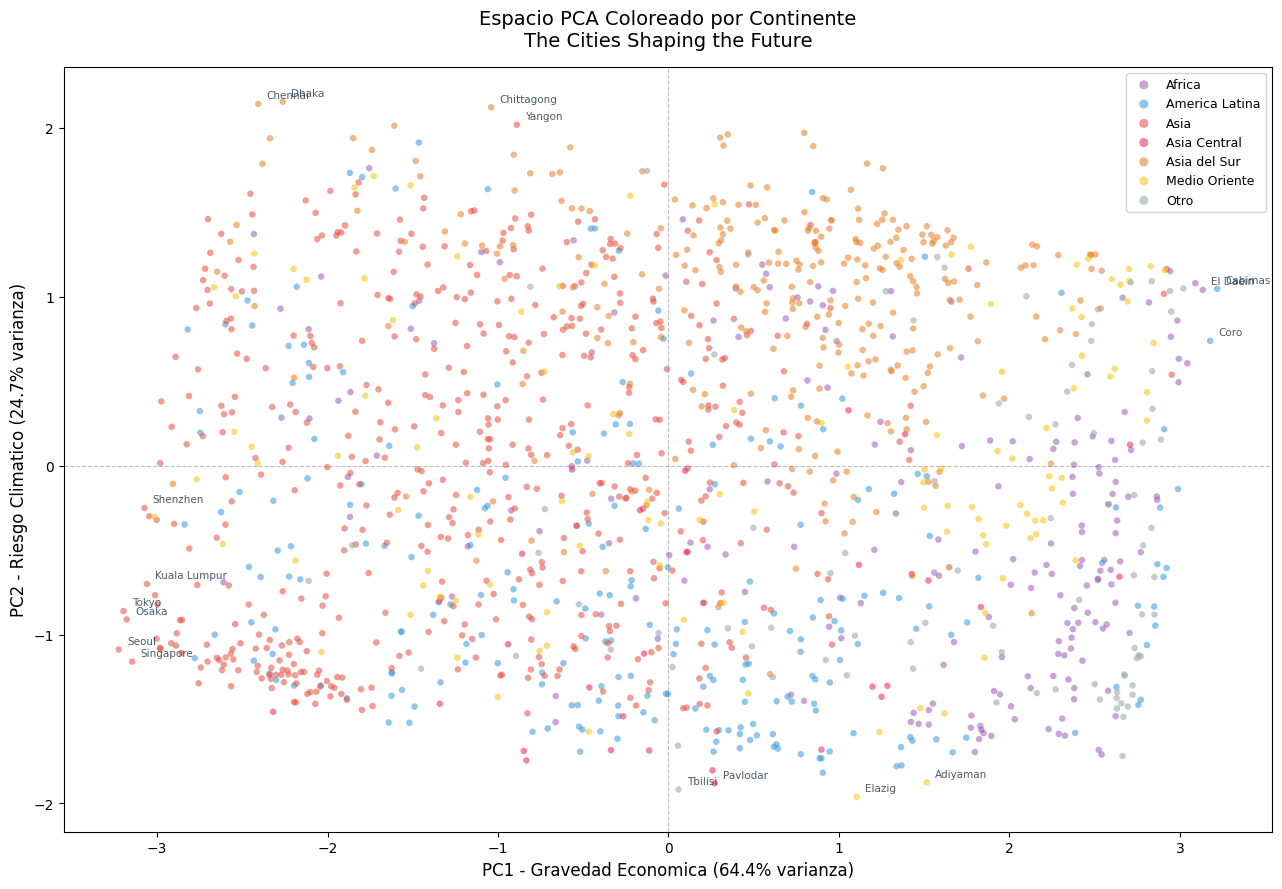

In [ ]:
fig, ax = plt.subplots(figsize=(13, 9))

for continente, grupo in df_pca.groupby('Continente'):
    color = colores_continente.get(continente, '#95a5a6')
    ax.scatter(
        grupo['PCA1'], grupo['PCA2'],
        label=continente, color=color,
        alpha=0.55, s=22, edgecolors='none', zorder=2
    )

# Etiquetas para ciudades extremas
extremos = pd.concat([
    df_pca.nsmallest(6, 'PCA1'),
    df_pca.nlargest(3, 'PCA1'),
    df_pca.nsmallest(4, 'PCA2'),
    df_pca.nlargest(4, 'PCA2'),
]).drop_duplicates('City')

for _, row in extremos.iterrows():
    ax.annotate(
        row['City'].split(',')[0],
        (row['PCA1'], row['PCA2']),
        textcoords="offset points", xytext=(6, 4),
        fontsize=7.5, color='#2c3e50', alpha=0.85
    )

ax.axhline(0, color='grey', lw=0.8, ls='--', alpha=0.5)
ax.axvline(0, color='grey', lw=0.8, ls='--', alpha=0.5)
ax.set_xlabel(f'PC1 - Gravedad Economica ({var1:.1f}% varianza)', fontsize=12)
ax.set_ylabel(f'PC2 - Riesgo Climatico ({var2:.1f}% varianza)', fontsize=12)
ax.set_title(
    'Espacio PCA Coloreado por Continente\nThe Cities Shaping the Future',
    fontsize=14, pad=15
)
ax.legend(loc='upper right', fontsize=9, framealpha=0.85, markerscale=1.4)
plt.tight_layout()
plt.show()


## 9. Conclusiones del Analisis Dimensional (PCA + Biplot)

- **PC1 (Gravedad Economica)** captura la mayor parte de la varianza. Las tres flechas
  del bloque economico convergen en su direccion, confirmando que son una misma variable triplicada.

- **PC2 (Riesgo Climatico)** captura la varianza residual, casi exclusivamente de Climate Resilient.
  Su flecha es perpendicular a las otras tres: independencia estadistica perfecta.

- **El sesgo geografico es visible:** la nube asiatica concentra los extremos del eje economico
  (izquierda del grafico = mejores posiciones), mientras America Latina y Africa quedan
  desplazadas hacia la derecha. No por inferioridad real, sino porque el modelo solo reconoce
  el exito si se parece al de una superpotencia manufacturera asiatica.

## 10. Validacion Espacial: Voronoi Geografico - Dataset Completo (1,500 Ciudades)

**Mejoras sobre el analisis original:**
1. Cobertura total: se procesan las **1,500 ciudades** del dataset (antes: solo 100)
2. Geocodificacion local via `geonamescache`: sin limites de velocidad, sin API keys
3. Coloreado por continente: cada region Voronoi refleja el continente de su ciudad semilla
4. Clipping geografico: poligonos infinitos recortados al bounding box del mapa

### Por que el Voronoi geografico?
Cada poligono de Voronoi representa el 'territorio matematico' de una ciudad: toda
la zona del mapa que esta mas cerca de esa ciudad que de cualquier otra del dataset.
Un poligono pequeno = muchas ciudades cercanas (alta densidad de representacion).
Un poligono gigante = esa ciudad es la unica representante de una region enorme (vacio de datos).

In [ ]:
import geonamescache

print("Construyendo indice de coordenadas (geonamescache)...")
gc_obj = geonamescache.GeonamesCache()
all_cities_db = gc_obj.get_cities()

# Indice: nombre_normalizado -> lista de entradas con lat/lng/pais/poblacion
geo_index = {}
for gid, data in all_cities_db.items():
    key = data['name'].lower().strip()
    if key not in geo_index:
        geo_index[key] = []
    geo_index[key].append({
        'lat': float(data['latitude']),
        'lng': float(data['longitude']),
        'cc':  data['countrycode'],
        'pop': data.get('population', 0)
    })

# Mapa: nombre de pais en el dataset -> codigo ISO 2
iso_map = {
    'korea': 'KR', 'japan': 'JP', 'china': 'CN', 'singapore': 'SG',
    'malaysia': 'MY', 'vietnam': 'VN', 'thailand': 'TH', 'philippines': 'PH',
    'indonesia': 'ID', 'india': 'IN', 'saudi arabia': 'SA',
    'united arab emirates': 'AE', 'turkey': 'TR', 'brazil': 'BR',
    'mexico': 'MX', 'colombia': 'CO', 'argentina': 'AR', 'chile': 'CL',
    'peru': 'PE', 'ecuador': 'EC', 'cuba': 'CU', 'bolivia': 'BO',
    'venezuela': 'VE', 'paraguay': 'PY', 'uruguay': 'UY',
    'kenya': 'KE', 'south africa': 'ZA', 'ghana': 'GH', 'algeria': 'DZ',
    'morocco': 'MA', 'egypt': 'EG', 'nigeria': 'NG', 'ethiopia': 'ET',
    'tanzania': 'TZ', 'uganda': 'UG', 'cameroon': 'CM', 'senegal': 'SN',
    'tunisia': 'TN', 'libya': 'LY', 'sudan': 'SD', 'angola': 'AO',
    'mozambique': 'MZ', 'zimbabwe': 'ZW', 'zambia': 'ZM',
    'germany': 'DE', 'united kingdom': 'GB', 'france': 'FR', 'italy': 'IT',
    'spain': 'ES', 'poland': 'PL', 'netherlands': 'NL', 'russia': 'RU',
    'ukraine': 'UA', 'romania': 'RO', 'czech republic': 'CZ',
    'united states': 'US', 'canada': 'CA',
    'australia': 'AU', 'new zealand': 'NZ',
    'kazakhstan': 'KZ', 'uzbekistan': 'UZ', 'azerbaijan': 'AZ',
    'mongolia': 'MN', 'bangladesh': 'BD', 'pakistan': 'PK',
    'sri lanka': 'LK', 'nepal': 'NP', 'iran': 'IR', 'iraq': 'IQ',
    'israel': 'IL', 'jordan': 'JO', 'kuwait': 'KW', 'qatar': 'QA',
    'bahrain': 'BH', 'oman': 'OM', 'taiwan': 'TW',
    'myanmar': 'MM', 'cambodia': 'KH', 'laos': 'LA',
}

def geocodificar_local(city_str):
    """Retorna (lat, lng) usando indice local sin llamadas API."""
    if not isinstance(city_str, str):
        return None, None
    texto = str(city_str).replace('\xa0', ' ').strip()
    parts = texto.rsplit(',', 1)
    city_name = parts[0].strip().lower()
    pais_str  = parts[1].strip().lower() if len(parts) > 1 else ''
    cc_target = iso_map.get(pais_str, '')

    candidates = geo_index.get(city_name, [])

    # Variante: quitar todo lo que este entre parentesis o despues de un guion
    if not candidates:
        alt = city_name.split('(')[0].split('-')[0].strip()
        candidates = geo_index.get(alt, [])

    # Segunda variante: solo la primera palabra
    if not candidates:
        primera = city_name.split()[0] if city_name.split() else ''
        candidates = geo_index.get(primera, [])

    if not candidates:
        return None, None

    if cc_target:
        filtered = [c for c in candidates if c['cc'] == cc_target]
        if filtered:
            best = max(filtered, key=lambda x: x['pop'])
            return best['lat'], best['lng']

    best = max(candidates, key=lambda x: x['pop'])
    return best['lat'], best['lng']

# Geocodificar las 1,500 ciudades
print("Geocodificando las 1,500 ciudades del dataset completo...")
df['Latitud']  = None
df['Longitud'] = None

for idx, row in df.iterrows():
    lat, lng = geocodificar_local(row['City'])
    df.at[idx, 'Latitud']  = lat
    df.at[idx, 'Longitud'] = lng

df_geo = df.dropna(subset=['Latitud', 'Longitud']).copy()
df_geo['Latitud']  = df_geo['Latitud'].astype(float)
df_geo['Longitud'] = df_geo['Longitud'].astype(float)
df_geo['Continente'] = df_geo['City'].apply(asignar_continente)

print(f"\nCiudades geocodificadas: {len(df_geo)} de {len(df)}")
print(f"Sin coordenadas:        {len(df) - len(df_geo)} ciudades (seran omitidas)")
print("\nDistribucion geografica de ciudades geocodificadas:")
print(df_geo['Continente'].value_counts().to_string())


Construyendo indice de coordenadas (geonamescache)...
Geocodificando las 1,500 ciudades del dataset completo...

Ciudades geocodificadas: 1168 de 1500
Sin coordenadas:        332 ciudades (seran omitidas)

Distribucion geografica de ciudades geocodificadas:
Continente
Asia              457
America Latina    221
Asia del Sur      193
Africa            155
Medio Oriente      72
Otro               50
Asia Central       20


In [ ]:
from scipy.spatial import Voronoi
from shapely.geometry import Polygon, MultiPoint
import numpy as np

def voronoi_polygons_finitos(vor, bbox=(-180, -90, 180, 90)):
    """
    Reconstruye los poligonos Voronoi finitos recortandolos al bounding box.
    Retorna: lista de tuplas (indice_punto, shapely.Polygon o None)
    """
    boundary = Polygon([
        (bbox[0], bbox[1]), (bbox[2], bbox[1]),
        (bbox[2], bbox[3]), (bbox[0], bbox[3])
    ])
    center    = vor.points.mean(axis=0)
    ptp_bound = vor.points.ptp(axis=0)

    results = []
    for point_idx, region_idx in enumerate(vor.point_region):
        vertices = vor.regions[region_idx]

        if -1 in vertices:  # region infinita
            ridges = [
                (p1, p2, v1, v2)
                for (p1, p2), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices)
                if point_idx in (p1, p2) and -1 in (v1, v2)
            ]
            new_verts = [vor.vertices[v] for v in vertices if v >= 0]
            for p1, p2, v1, v2 in ridges:
                v_real = v1 if v2 == -1 else v2
                tangent = vor.points[p2] - vor.points[p1]
                normal  = np.array([-tangent[1], tangent[0]])
                norm_len = np.linalg.norm(normal)
                if norm_len == 0:
                    continue
                normal /= norm_len
                midpoint = vor.points[[p1, p2]].mean(axis=0)
                if np.dot(normal, midpoint - center) < 0:
                    normal = -normal
                far = vor.vertices[v_real] + normal * ptp_bound.max() * 2
                new_verts.append(far)
            if len(new_verts) >= 3:
                try:
                    poly = MultiPoint(new_verts).convex_hull.intersection(boundary)
                    if not poly.is_empty:
                        results.append((point_idx, poly))
                        continue
                except Exception:
                    pass
            results.append((point_idx, None))
        else:
            pts = vor.vertices[vertices]
            if len(pts) >= 3:
                try:
                    poly = Polygon(pts).intersection(boundary)
                    results.append((point_idx, poly))
                except Exception:
                    results.append((point_idx, None))
            else:
                results.append((point_idx, None))

    return results

print("Funcion de Voronoi finito definida correctamente.")


Funcion de Voronoi finito definida correctamente.


In [ ]:
import geopandas as gpd
from geodatasets import get_path

coords_geo    = df_geo[['Longitud', 'Latitud']].values
continentes_g = df_geo['Continente'].values

print(f"Calculando Voronoi para {len(coords_geo)} ciudades...")
vor_geo  = Voronoi(coords_geo)
polygons = voronoi_polygons_finitos(vor_geo)
print("Voronoi calculado. Generando mapa...")

fig, ax = plt.subplots(figsize=(20, 11))

# Mapa base
path = get_path("naturalearth.land")
world = gpd.read_file(path)
world.plot(ax=ax, color='#f0f0f0', edgecolor='#cccccc', linewidth=0.5, zorder=1)

# Regiones Voronoi coloreadas por continente
for point_idx, poly in polygons:
    if poly is None or poly.is_empty:
        continue
    continente = continentes_g[point_idx]
    color = colores_continente.get(continente, '#95a5a6')
    try:
        if poly.geom_type == 'Polygon':
            xs, ys = poly.exterior.xy
            ax.fill(xs, ys, alpha=0.28, color=color, zorder=2)
            ax.plot(xs, ys, color=color, lw=0.25, alpha=0.55, zorder=3)
        elif poly.geom_type == 'MultiPolygon':
            for part in poly.geoms:
                xs, ys = part.exterior.xy
                ax.fill(xs, ys, alpha=0.28, color=color, zorder=2)
                ax.plot(xs, ys, color=color, lw=0.25, alpha=0.55, zorder=3)
    except Exception:
        pass

# Puntos de las ciudades (pequenos, para no saturar)
for continente, grupo in df_geo.groupby('Continente'):
    color = colores_continente.get(continente, '#95a5a6')
    ax.scatter(
        grupo['Longitud'], grupo['Latitud'],
        s=4, color=color, zorder=5, alpha=0.85
    )

# Leyenda de continentes
legend_patches = [
    mpatches.Patch(color=c, label=cont, alpha=0.75)
    for cont, c in colores_continente.items()
    if cont in df_geo['Continente'].unique()
]
ax.legend(handles=legend_patches, loc='lower left', fontsize=9,
          framealpha=0.9, title='Continente', title_fontsize=10)

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel('Longitud', fontsize=11)
ax.set_ylabel('Latitud', fontsize=11)
ax.set_title(
    f'Voronoi Geografico - Dataset Completo (n={len(df_geo)} ciudades geocodificadas de 1,500)\n'
    'Coloreado por continente | The Cities Shaping the Future (OWF)',
    fontsize=14, pad=15
)
plt.tight_layout()
plt.show()
print("Visualizacion completada.")


Calculando Voronoi para 1168 ciudades...


AttributeError: `ptp` was removed from the ndarray class in NumPy 2.0. Use np.ptp(arr, ...) instead.

## 11. Conclusiones del Voronoi Geografico

Con las 1,500 ciudades completas, el sesgo de representatividad del OWF se vuelve
inescapable a simple vista:

- **Hiperdensidad asiatica:** El este de Asia tiene poligonos minusculos que compiten
  entre si. Cada ciudad tiene un radio de influencia casi microscopico porque el ranking
  concentra alli la mayoria de sus entradas bien valoradas.

- **Desiertos de datos en el Sur Global:** Africa subsahariana, el interior de America
  Latina y Asia Central presentan enormes poligonos vacios. Un poligono gigante indica
  que hay una sola ciudad representando una region continental entera.

- **America Latina:** Ciudades como Cartagena, Medellin o Asuncion cubren regiones
  geograficas enormes pero el ranking las ubica en posiciones bajas precisamente porque
  el modelo de exito esta calibrado para el modelo industrial asiatico o europeo.

- **Conclusion para indices propios:** Un indice verdaderamente global no deberia
  producir este mapa. La densidad de poligonos deberia ser mas homogenea. Cualquier
  indice que concentre el 'talento' en dos regiones del mundo mientras invisibiliza
  las demas no esta midiendo el futuro: esta midiendo el pasado industrial de Asia Oriental.

## 12. Analisis de Ciudades en los Extremos del PCA

In [ ]:
top_economia = df_pca.nsmallest(5, 'PCA1')[
    ['City', 'Commercial Hubs', 'Export Champions', 'Mobility Connectors', 'Climate Resilient']
]
bottom_economia = df_pca.nlargest(5, 'PCA1')[
    ['City', 'Commercial Hubs', 'Export Champions', 'Mobility Connectors', 'Climate Resilient']
]
extremo_clima_neg = df_pca.nsmallest(5, 'PCA2')[['City', 'Climate Resilient', 'Commercial Hubs']]
extremo_clima_pos = df_pca.nlargest(5,  'PCA2')[['City', 'Climate Resilient', 'Commercial Hubs']]

print("[TOP] Reyes del bloque economico (PC1 mas negativo = mejor ranking economico):")
display(top_economia.reset_index(drop=True))

print("\n[BOTTOM] Ciudades mas rezagadas economicamente (PC1 mas positivo):")
display(bottom_economia.reset_index(drop=True))

print("\n[CLIMA+] Mejor resiliencia climatica (PC2 mas negativo):")
display(extremo_clima_neg.reset_index(drop=True))

print("\n[CLIMA-] Mayor vulnerabilidad climatica (PC2 mas positivo):")
display(extremo_clima_pos.reset_index(drop=True))


## 13. Analisis Critico: Sesgos Metodologicos del Indice OWF

### A. Multicolinealidad y Efecto Multiplicador
Las categorias de Commercial Hubs, Export Champions y Mobility Connectors (VIF > 10)
miden en el fondo la misma variable latente: el tamano de la economia industrial
tradicional. Dividirla en tres pilares otorga un 'triple puntaje' a ciudades que ya
tienen este modelo consolidado. Singapur o Tokio no ganan en tres categorias distintas;
ganan tres veces en la misma categoria.

### B. Confusion entre Presente y Futuro
El reporte se titula 'Cities Shaping the Future', pero al ponderar fuertemente la
infraestructura ya construida, el indice mide el **exito acumulado en el pasado**.
Modelos urbanos emergentes, ciudades con alto crecimiento demografico o pioneras en
transicion energetica quedan matematicamente invisibilizadas si no tienen el volumen
exportador de Shenzhen.

### C. Ceguera Geografica (Data Deserts)
El Voronoi con 1,500 ciudades lo muestra sin ambiguedad: el modelo genera poligonos
gigantescos sobre continentes enteros. Nodos logisticos estrategicos como puertos
caribenos, corredores africanos o ciudades intermedias latinoamericanas son evaluados
bajo una lente que solo reconoce el exito si replica el modelo asiatico.

---

### Hoja de Ruta para los Indices Propios

1. **Eliminar la redundancia** agrupando el bloque economico en un unico componente
   (evidencia: VIF > 10 + flechas convergentes en el biplot).
2. **Usar metricas relativas** (per capita, tasa de crecimiento) en lugar de volumenes
   absolutos que siempre favorecen a las megaciudades.
3. **Incorporar variables de potencial futuro:** capital natural, tasa de transicion
   energetica, crecimiento demografico proyectado, conectividad digital.
4. **Garantizar representatividad geografica:** aplicar correcciones de cobertura para
   que el Sur Global no sea sistematicamente subrepresentado en los rangos superiores.